# 01 · Tensor 與 autograd

歡迎來到 **機器學習 → 深度學習入門（PyTorch）**。

前面的 sklearn / XGBoost 都是「呼叫現成模型」。深度學習不一樣——你要**自己搭神經網路**。但別怕，PyTorch 的兩塊地基其實很單純：**Tensor**（會算梯度的陣列）與 **autograd**（自動微分）。這堂課把這兩塊打牢。

> 💡 神經網路的訓練 = 不斷算「loss 對每個參數的梯度」再往下走。autograd 幫你自動算梯度——這是整個深度學習的引擎。建議在 Colab 開啟（之後幾課可開免費 GPU）。

## 學習目標

- 建立、操作 **Tensor**，知道它跟 NumPy 陣列的關係
- 理解 `requires_grad` 與 `backward()` 如何自動算梯度
- 親手驗證 autograd 算出的梯度跟手算的一致

## 1. Tensor：會算梯度的陣列

Tensor 就像 NumPy 的 `ndarray`，支援一樣的運算與 broadcasting——但它多了兩個超能力：能跑在 GPU 上、能自動算梯度。

In [1]:
import torch

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("tensor:\n", x)
print("形狀:", x.shape, " dtype:", x.dtype)
print("矩陣相乘 x @ x:\n", x @ x)
print("跟 NumPy 互通:", x.numpy().sum())

tensor:
 tensor([[1., 2.],
        [3., 4.]])
形狀: torch.Size([2, 2])  dtype: torch.float32
矩陣相乘 x @ x:
 tensor([[ 7., 10.],
        [15., 22.]])
跟 NumPy 互通: 10.0


## 2. autograd：自動微分

把 `requires_grad=True` 設給一個 tensor，PyTorch 就會**記錄所有對它做的運算**，組成一張計算圖。呼叫 `.backward()`，它會沿著圖反向把梯度算出來，存在 `.grad` 裡。

用最簡單的 `y = x²` 驗證：手算 dy/dx = 2x，在 x=3 應該是 6。

In [2]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()              # 反向傳播，算 dy/dx
print(f"x = {x.item()}")
print(f"autograd 算出的 dy/dx = {x.grad.item()}   (手算 2x = {2 * x.item()})")

x = 3.0
autograd 算出的 dy/dx = 6.0   (手算 2x = 6.0)


完全一致。再看一個多變數的例子，並把梯度當成「往哪走能讓 y 變小」的方向——這正是訓練神經網路在做的事。

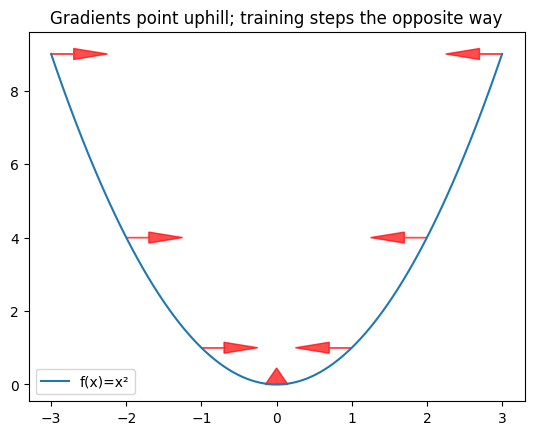

梯度 (dy/dx): [-6. -4. -2.  0.  2.  4.  6.]


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# f(x) = x^2，在好幾個點上用 autograd 取梯度，畫出切線方向
xs = torch.linspace(-3, 3, 7, requires_grad=True)
ys = xs ** 2
ys.sum().backward()       # 對每個 x 取梯度

xs_np = xs.detach().numpy()
grads = xs.grad.numpy()
curve_x = np.linspace(-3, 3, 100)
plt.plot(curve_x, curve_x ** 2, label="f(x)=x²")
for xi, yi, g in zip(xs_np, xs_np ** 2, grads):
    plt.arrow(xi, yi, -0.3 * np.sign(g), 0, head_width=0.3, color="red", alpha=0.7)
plt.title("Gradients point uphill; training steps the opposite way")
plt.legend(); plt.show()
print("梯度 (dy/dx):", grads.round(2))

紅箭頭是「梯度的反方向」——也就是讓 y 下降的方向。訓練時，optimizer 就是讓每個參數沿著梯度反方向走一小步，一步一步把 loss 降下去。

## 小結

- **Tensor** = 會算梯度、能上 GPU 的 NumPy 陣列。
- `requires_grad=True` 讓 PyTorch 記錄運算，`backward()` 自動算梯度到 `.grad`。
- 訓練 = 沿梯度反方向走，逐步降低 loss。

## 練習

1. 對 `y = x**3 + 2*x` 在 x=2 用 autograd 求導，跟手算 `3x²+2` 比對。
2. 用 `torch.zeros(3, requires_grad=True)` 造一個向量，對 `y = (x**2).sum()` 反傳，看 `.grad`。

下一課，用這些零件**搭出第一個神經網路**。